<a href="https://colab.research.google.com/github/MiguelAngeloTr/Aprendizaje_Automatico/blob/main/SEMANA_7/EjercicioCancer_Vext.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Paso 1: Subir archivo desde tu computadora
from google.colab import files
uploaded = files.upload()


Saving df_train.parquet to df_train.parquet


In [ ]:
# Paso 2: Importar pandas y leer el archivo .parquet
import pandas as pd

# Leer el archivo parquet (debe haberse subido con el mismo nombre)
df = pd.read_parquet('df_train.parquet')


# Mostrar las primeras filas
df.head()


,GENERO,ESTADO_CIVIL,FECHA_NACIMIENTO,CODIGO_SEDE,MULTI_CANCER,CESION,RIESGOS,CANCER_MAMA_FAMILIAR,CANCER_OTRO_SITIO,CANCER_OTRO_SITIO_FAMILIAR,...,radioterapias_cancer,quimioterapias__cancer,hormonoterapias__cancer,cuidado_palitiavo__cancer,inmunoterapias_cancer,Citas_oncologicas_cancer,psiquiatria_cancer,psicologia_cancer,nutricion_cancer,atencion_nutricion
ID,,,,,,,,,,,,,,,,,,,,,
2987,F,SO,1977-01-17,1051,None,0,2.0,0,0,1,...,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,Sin servicios nutricion
3423,F,CA,1980-10-13,1028,None,0,1.0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,5.0,1.0,1.0,0.0,Sin servicios nutricion
6981,F,SO,1951-10-28,1022,None,0,3.0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,Una servicio nutricion
6701,F,SO,1984-03-31,1026,None,0,1.0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,Sin servicios nutricion
7361,F,UL,1974-03-28,1007,None,0,1.0,0,0,0,...,0.0,1.0,0.0,0.0,0.0,7.0,0.0,0.0,0.0,Sin servicios nutricion


In [ ]:
print(df.shape)

(3955, 42)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3955 entries, 2987 to 898
Data columns (total 42 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   GENERO                      3955 non-null   object        
 1   ESTADO_CIVIL                3955 non-null   object        
 2   FECHA_NACIMIENTO            3955 non-null   datetime64[us]
 3   CODIGO_SEDE                 3955 non-null   object        
 4   MULTI_CANCER                337 non-null    object        
 5   CESION                      3955 non-null   object        
 6   RIESGOS                     3955 non-null   float64       
 7   CANCER_MAMA_FAMILIAR        3955 non-null   object        
 8   CANCER_OTRO_SITIO           3955 non-null   object        
 9   CANCER_OTRO_SITIO_FAMILIAR  3955 non-null   object        
 10  CEREBRAL_FAMILIAR           3955 non-null   object        
 11  FECHA_DATOS_PESO_TALLA      3955 non-null   datetime64[us]


In [ ]:
df.isnull().sum()

,0
GENERO,0
ESTADO_CIVIL,0
FECHA_NACIMIENTO,0
CODIGO_SEDE,0
MULTI_CANCER,3618
CESION,0
RIESGOS,0
CANCER_MAMA_FAMILIAR,0
CANCER_OTRO_SITIO,0
CANCER_OTRO_SITIO_FAMILIAR,0


In [ ]:
df["Target"].value_counts().to_frame()

,count
Target,
0.0,3508
1.0,447


In [ ]:
# Ver las columnas categóricas (object)
cat_cols = df.select_dtypes(include='object').columns.tolist()
print("Categóricas:", cat_cols)

# Ver las columnas numéricas (float)
num_cols = df.select_dtypes(include='float').columns.tolist()
print("Numéricas:", num_cols)

# Ver columnas de tipo fecha (datetime)
date_cols = df.select_dtypes(include='datetime').columns.tolist()
print("Fechas:", date_cols)


Categóricas: ['GENERO', 'ESTADO_CIVIL', 'CODIGO_SEDE', 'MULTI_CANCER', 'CESION', 'CANCER_MAMA_FAMILIAR', 'CANCER_OTRO_SITIO', 'CANCER_OTRO_SITIO_FAMILIAR', 'CEREBRAL_FAMILIAR', 'atencion_nutricion']
Numéricas: ['RIESGOS', 'PESO', 'TALLA', 'TSISTOLICA', 'TDIASTOLICA', 'Target', 'mes_6', 'mes_5', 'mes_4', 'mes_3', 'mes_2', 'mes_1', 'valor_servicio', 'IV_NIVEL', 'HOSPI_NO_QUIRURGICA', 'URGENCIAS', 'HOSPITALIZACION', 'CITA_ONCOLOGICA', 'Biopsias_cancer', 'radioterapias_cancer', 'quimioterapias__cancer', 'hormonoterapias__cancer', 'cuidado_palitiavo__cancer', 'inmunoterapias_cancer', 'Citas_oncologicas_cancer', 'psiquiatria_cancer', 'psicologia_cancer', 'nutricion_cancer']
Fechas: ['FECHA_NACIMIENTO', 'FECHA_DATOS_PESO_TALLA', 'FECHA_CONSULTA_TENSION', 'Fecha_cero']


# **Analísis de Características tipo: Numéricas**

In [ ]:


# Ver columnas numéricas con valores faltantes
missing_num_cols = df[num_cols].isnull().sum()
missing_num_cols = missing_num_cols[missing_num_cols > 0]

# Mostrar columnas con faltantes y cuántos faltan
print("Variables numéricas con valores faltantes:")
print(missing_num_cols)

# Filtrar columnas con datos faltantes
missing_num_cols_names = df[num_cols].columns[df[num_cols].isnull().any()].tolist()
print("Nombres de las columnas numéricas con faltantes:")
print(missing_num_cols_names)

Variables numéricas con valores faltantes:
PESO           133
TALLA          133
TSISTOLICA     140
TDIASTOLICA    140
dtype: int64
Nombres de las columnas numéricas con faltantes:
['PESO', 'TALLA', 'TSISTOLICA', 'TDIASTOLICA']


Validando distribución visual de los histogramas para las características numércias con valores faltantes:

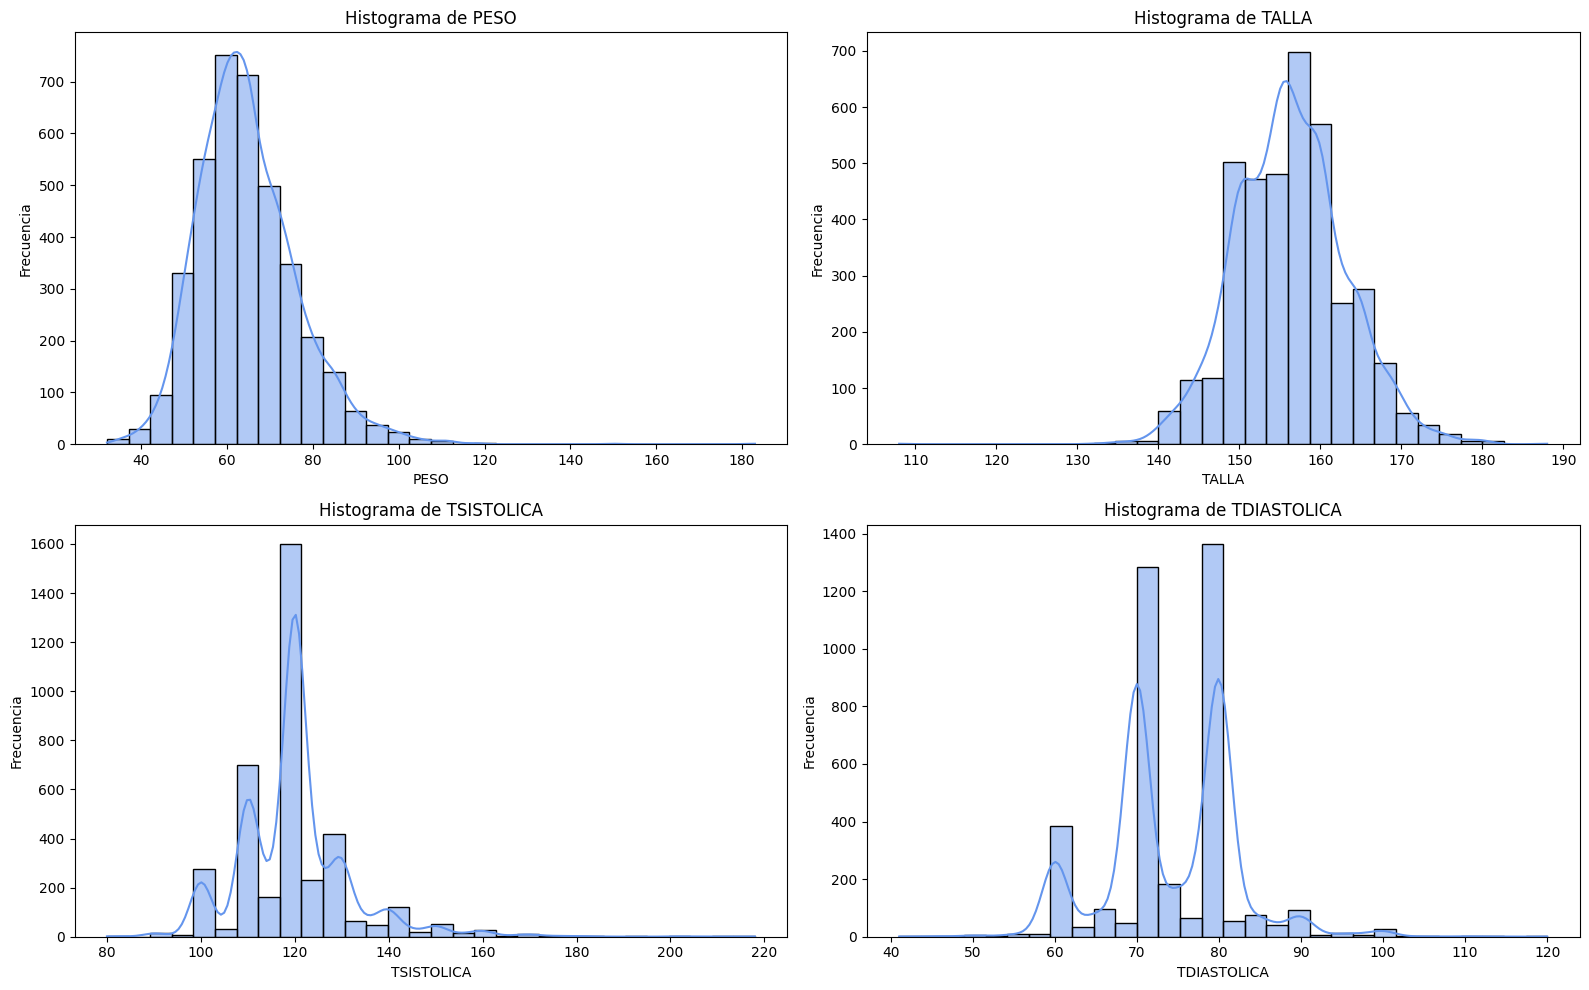

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Graficar los histogramas
plt.figure(figsize=(16, 10))

for i, col in enumerate(missing_num_cols_names, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df[col].dropna(), kde=True, bins=30, color='cornflowerblue')
    plt.title(f'Histograma de {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()

Usando boxplots:

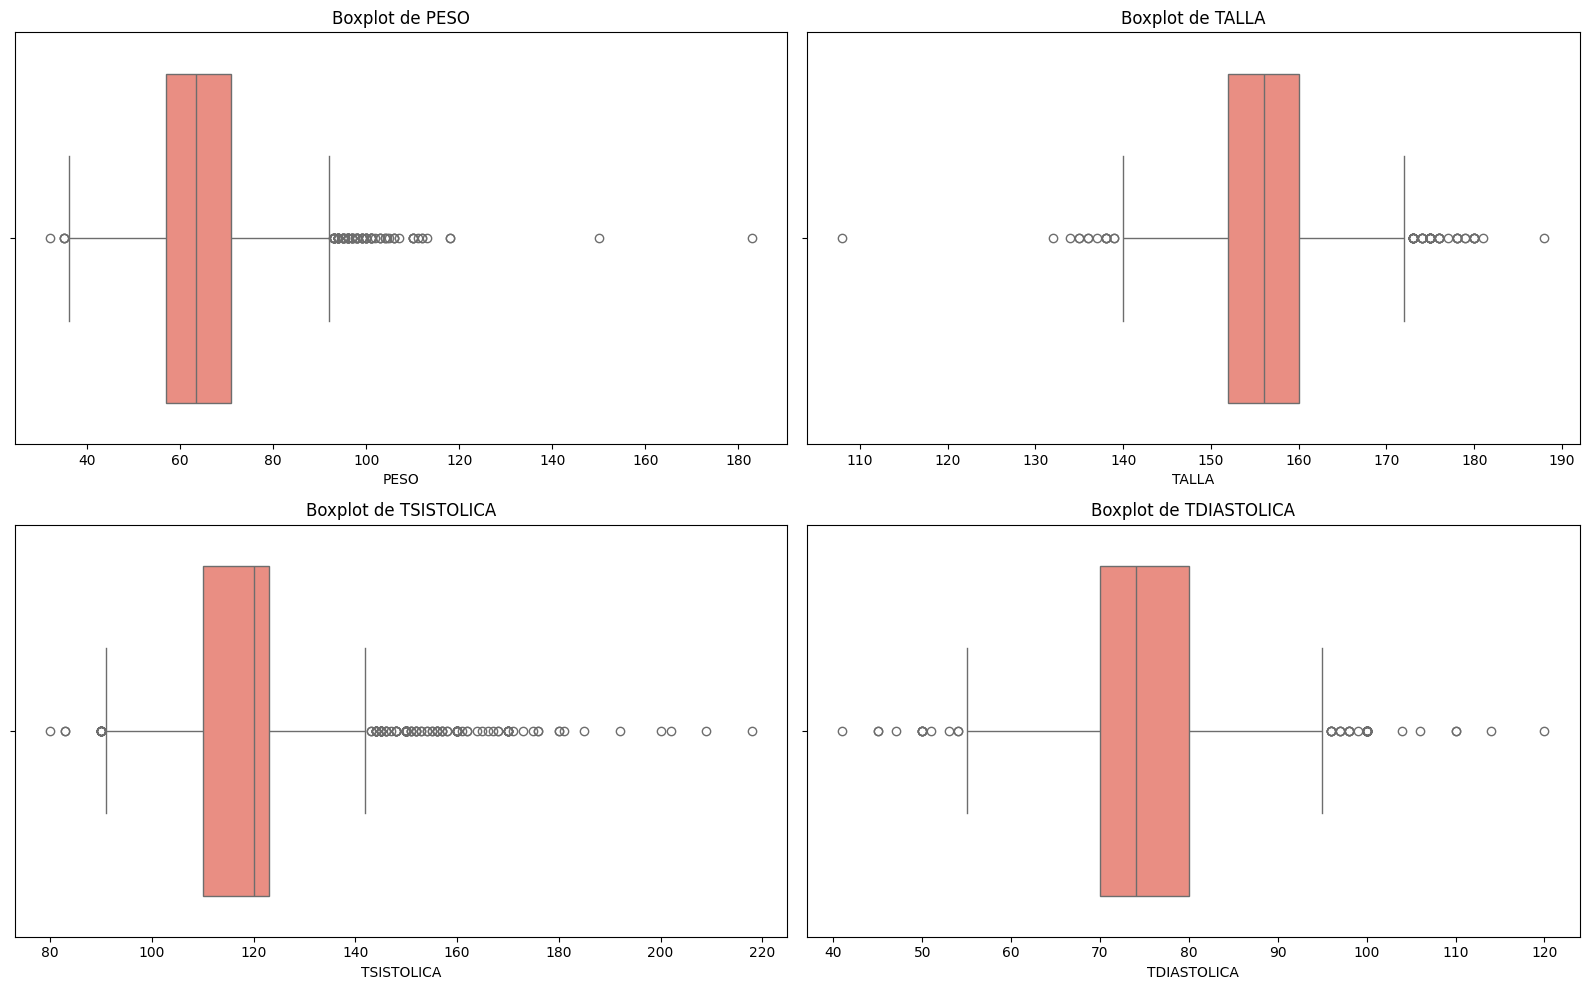

In [ ]:
plt.figure(figsize=(16, 10))

for i, col in enumerate(missing_num_cols_names, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x=df[col], color='salmon')
    plt.title(f'Boxplot de {col}')
    plt.xlabel(col)

plt.tight_layout()
plt.show()


**Usando test formales para validación si una distribución es normal o no:**

# **Shapiro-Wilk Test**

**Hipótesis nula H₀:** La variable tiene distribución normal.

**Hipótesis alternativa H₁:** La variable no tiene distribución normal.

Se usa con muestras pequeñas y medianas (n < 5000).

**Fórmula conceptual:** Compara los cuantiles ordenados de la muestra con los de una normal teórica.

In [ ]:
from scipy.stats import shapiro

for col in missing_num_cols_names:
    stat, p = shapiro(df[col].dropna())
    print(f'{col}: Shapiro-Wilk p-value = {p:.5f} --> {"Normal" if p > 0.05 else "No normal"}')


PESO: Shapiro-Wilk p-value = 0.00000 --> No normal
TALLA: Shapiro-Wilk p-value = 0.00000 --> No normal
TSISTOLICA: Shapiro-Wilk p-value = 0.00000 --> No normal
TDIASTOLICA: Shapiro-Wilk p-value = 0.00000 --> No normal


# **D’Agostino y Pearson Test**

Combina:

Skewness (asimetría) y Kurtosis (forma de la cola)

Se recomienda con n > 20.

Hipótesis nula: la variable tiene distribución normal.

In [ ]:
from scipy.stats import normaltest

for col in missing_num_cols_names:
    stat, p = normaltest(df[col].dropna())
    print(f'{col}: D’Agostino p-value = {p:.5f} --> {"Normal" if p > 0.05 else "No normal"}')


PESO: D’Agostino p-value = 0.00000 --> No normal
TALLA: D’Agostino p-value = 0.00000 --> No normal
TSISTOLICA: D’Agostino p-value = 0.00000 --> No normal
TDIASTOLICA: D’Agostino p-value = 0.00000 --> No normal


# **Kolmogorov–Smirnov (K–S) Test**

*   Compara la distribución empírica con la normal teórica.
*   Hipótesis nula: la variable sigue una distribución normal.
*   No es robusto con datos con parámetros (media y varianza) estimados de la misma muestra.










In [ ]:
from scipy.stats import kstest, norm

for col in missing_num_cols_names:
    data = df[col].dropna()
    stat, p = kstest(data, 'norm', args=(data.mean(), data.std()))
    print(f'{col}: Kolmogorov-Smirnov p-value = {p:.5f} --> {"Normal" if p > 0.05 else "No normal"}')


PESO: Kolmogorov-Smirnov p-value = 0.00000 --> No normal
TALLA: Kolmogorov-Smirnov p-value = 0.00000 --> No normal
TSISTOLICA: Kolmogorov-Smirnov p-value = 0.00000 --> No normal
TDIASTOLICA: Kolmogorov-Smirnov p-value = 0.00000 --> No normal


# **Lilliefors Test (Kolmogorov adaptado)**

Es una versión del K–S test que corrige el problema de estimar la media y varianza desde la muestra.

In [ ]:
from statsmodels.stats.diagnostic import lilliefors

for col in missing_num_cols_names:
    stat, p = lilliefors(df[col].dropna())
    print(f'{col}: Lilliefors p-value = {p:.5f} --> {"Normal" if p > 0.05 else "No normal"}')


PESO: Lilliefors p-value = 0.00100 --> No normal
TALLA: Lilliefors p-value = 0.00100 --> No normal
TSISTOLICA: Lilliefors p-value = 0.00100 --> No normal
TDIASTOLICA: Lilliefors p-value = 0.00100 --> No normal


In [ ]:
!pip install statsmodels


In [ ]:
from scipy.stats import shapiro, normaltest, kstest, norm
from statsmodels.stats.diagnostic import lilliefors
import pandas as pd

def evaluar_normalidad(df, columnas):
    resultados = []

    for col in columnas:
        data = df[col].dropna()

        if len(data) < 8:
            print(f"⚠️ Columna {col} tiene menos de 8 valores no nulos. Saltando test.")
            continue

        # Shapiro-Wilk
        try:
            shapiro_p = shapiro(data)[1]
        except Exception as e:
            shapiro_p = None

        # D’Agostino and Pearson
        try:
            dagostino_p = normaltest(data)[1]
        except Exception as e:
            dagostino_p = None

        # Kolmogorov–Smirnov (comparado contra normal con misma media y std)
        try:
            ks_p = kstest(data, 'norm', args=(data.mean(), data.std()))[1]
        except Exception as e:
            ks_p = None

        # Lilliefors
        try:
            lillie_p = lilliefors(data)[1]
        except Exception as e:
            lillie_p = None

        resultados.append({
            'Variable': col,
            'Shapiro p-value': shapiro_p,
            'Shapiro Resultado': 'Normal' if shapiro_p and shapiro_p > 0.05 else 'No normal',
            'D’Agostino p-value': dagostino_p,
            'D’Agostino Resultado': 'Normal' if dagostino_p and dagostino_p > 0.05 else 'No normal',
            'KS p-value': ks_p,
            'KS Resultado': 'Normal' if ks_p and ks_p > 0.05 else 'No normal',
            'Lilliefors p-value': lillie_p,
            'Lilliefors Resultado': 'Normal' if lillie_p and lillie_p > 0.05 else 'No normal',
        })

    return pd.DataFrame(resultados)


In [ ]:
# Aplicar la función a las columnas con valores faltantes numéricos
tabla_normalidad = evaluar_normalidad(df, missing_num_cols_names)

# Reorganizar para mostrar horizontalmente
tabla_horizontal = tabla_normalidad.set_index('Variable').T

# Mostrar
display(tabla_horizontal)


Variable,PESO,TALLA,TSISTOLICA,TDIASTOLICA
Shapiro p-value,0.0,0.0,0.0,0.0
Shapiro Resultado,No normal,No normal,No normal,No normal
D’Agostino p-value,0.0,0.0,0.0,0.0
D’Agostino Resultado,No normal,No normal,No normal,No normal
KS p-value,0.0,0.0,0.0,0.0
KS Resultado,No normal,No normal,No normal,No normal
Lilliefors p-value,0.001,0.001,0.001,0.001
Lilliefors Resultado,No normal,No normal,No normal,No normal


In [ ]:
# Paso 1: función para eliminar outliers usando Z-score
def eliminar_outliers_zscore(df, columnas, umbral=3):
    df_filtrado = df[columnas].copy()
    for col in columnas:
        serie = df_filtrado[col]
        media = serie.mean()
        std = serie.std()
        z_scores = (serie - media) / std
        df_filtrado = df_filtrado[z_scores.abs() <= umbral]
    return df_filtrado

# Paso 2: eliminar outliers en las columnas numéricas con NA
df_sin_outliers = eliminar_outliers_zscore(df, missing_num_cols_names, umbral=3)

# Paso 3: aplicar la función que ya tienes para evaluar normalidad
tabla_normalidad_sin_outliers = evaluar_normalidad(df_sin_outliers, missing_num_cols_names)

# Reorganizar para mostrar horizontalmente
tabla_horizontal_sinOut = tabla_normalidad_sin_outliers.set_index('Variable').T

# Mostrar
display(tabla_horizontal_sinOut)

Variable,PESO,TALLA,TSISTOLICA,TDIASTOLICA
Shapiro p-value,0.0,0.0,0.0,0.0
Shapiro Resultado,No normal,No normal,No normal,No normal
D’Agostino p-value,0.0,0.001416,0.0,0.0
D’Agostino Resultado,No normal,No normal,No normal,No normal
KS p-value,0.0,0.0,0.0,0.0
KS Resultado,No normal,No normal,No normal,No normal
Lilliefors p-value,0.001,0.001,0.001,0.001
Lilliefors Resultado,No normal,No normal,No normal,No normal


# **Conclusión:**

1. **No guiarse ciegamente en los test estadísticos:**

Los tests de normalidad son muy sensibles cuando se tiene muchos datos (>500), y muchas veces rechazan la hipótesis nula de normalidad por pequeños desvíos, aunque esos no sean importantes para el objetivo.

2. **Confiar en la inspección visual + contexto:**

Si al ver los histogramas y boxplots notas que:

No hay sesgo fuerte (simetría razonable).

No hay demasiados outliers.

No hay multimodalidad (picos dobles o más).




**Resumen práctico de imputación**

-  **Si hay outliers** → Imputar con **Mediana**
-  **Distribución normal + sin outliers** → Imputar con **Media** *(no aplica para este caso)*
- **Si hay duda entre media o mediana** → Usar **Mediana** es más segura

### 🩺 Imputación recomendada para variables numéricas con valores faltantes

| Variable      | Distribución visual | Outliers | Imputación recomendada |
| ------------- | ------------------- | -------- | ---------------------- |
| `PESO`        | Casi normal         | Muchos   | ✅ **Mediana**          |
| `TALLA`       | Casi normal         | Muchos   | ✅ **Mediana**          |
| `TSISTOLICA`  | No normal           | Sí       | ✅ Mediana              |
| `TDIASTOLICA` | No normal           | Sí       | ✅ Mediana              |


In [ ]:
# Imputación con mediana para todas porque hay outliers en todas
for col in ['PESO', 'TALLA', 'TSISTOLICA', 'TDIASTOLICA']:
    df[col].fillna(df[col].median(), inplace=True)


<ipython-input-19-65fe1f0c4d48>:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


Se revalida que no hay faltantes ahora de las características que son tipo numéricas:

In [ ]:
# Ver columnas numéricas con valores faltantes
missing_num_cols_after = df[num_cols].isnull().sum()
missing_num_cols_after = missing_num_cols_after[missing_num_cols_after > 0]

# Mostrar columnas con faltantes y cuántos faltan
print("Variables numéricas con valores faltantes:")
print(missing_num_cols_after)

Variables numéricas con valores faltantes:
Series([], dtype: int64)


# **Analísis de Características tipo: Categóricas**

In [ ]:
# Ver valores únicos por cada columna categórica
for col in cat_cols:
    print(f"📌 {col}: {df[col].unique()} \n")


📌 GENERO: ['F' 'M'] 

📌 ESTADO_CIVIL: ['SO' 'CA' 'UL' 'VI' 'SE'] 

📌 CODIGO_SEDE: [Decimal('1051') Decimal('1028') Decimal('1022') Decimal('1026')
 Decimal('1007') Decimal('1052') Decimal('4032') Decimal('1001')
 Decimal('0') Decimal('1142') Decimal('25012') Decimal('1189')
 Decimal('1057') Decimal('1158') Decimal('5030') Decimal('1016')
 Decimal('3109') Decimal('1015') Decimal('1191') Decimal('1010')
 Decimal('1067') Decimal('1134') Decimal('1155') Decimal('1059')
 Decimal('7019') Decimal('1223') Decimal('1068') Decimal('1112')
 Decimal('1096') Decimal('1024') Decimal('1192') Decimal('3021')
 Decimal('1193') Decimal('2018') Decimal('3003') Decimal('1153')
 Decimal('1099') Decimal('1066') Decimal('1115') Decimal('1008')
 Decimal('1131') Decimal('2033') Decimal('1065') Decimal('4031')
 Decimal('1025') Decimal('12001') Decimal('1117') Decimal('3116')
 Decimal('3118') Decimal('10006') Decimal('4033') Decimal('3018')
 Decimal('1133') Decimal('3117') Decimal('3046') Decimal('29010')
 Decima

In [ ]:
# Mostrar conteo de valores únicos por variable categórica
for col in cat_cols:
    print(f"📌 {col} → únicos: {df[col].nunique()}")
    print(df[col].value_counts(dropna=False), "\n")


📌 GENERO → únicos: 2
GENERO
F    3848
M     107
Name: count, dtype: int64 

📌 ESTADO_CIVIL → únicos: 5
ESTADO_CIVIL
SO    1675
CA    1500
UL     591
SE     113
VI      76
Name: count, dtype: int64 

📌 CODIGO_SEDE → únicos: 98
CODIGO_SEDE
1007     578
1015     312
1022     249
1052     248
1059     248
        ... 
20011      1
8022       1
2043       1
4005       1
9014       1
Name: count, Length: 98, dtype: int64 

📌 MULTI_CANCER → únicos: 2
MULTI_CANCER
None    3618
1        317
2         20
Name: count, dtype: int64 

📌 CESION → únicos: 2
CESION
0    3653
1     302
Name: count, dtype: int64 

📌 CANCER_MAMA_FAMILIAR → únicos: 2
CANCER_MAMA_FAMILIAR
0    3622
1     333
Name: count, dtype: int64 

📌 CANCER_OTRO_SITIO → únicos: 2
CANCER_OTRO_SITIO
0    3159
1     796
Name: count, dtype: int64 

📌 CANCER_OTRO_SITIO_FAMILIAR → únicos: 2
CANCER_OTRO_SITIO_FAMILIAR
0    3225
1     730
Name: count, dtype: int64 

📌 CEREBRAL_FAMILIAR → únicos: 2
CEREBRAL_FAMILIAR
0    3882
1      73
Name: co

| Variable                     | Valores únicos / Observación                              | Tipo          | Tratamiento recomendado            |
|-----------------------------|------------------------------------------------------------|---------------|------------------------------------|
| `GENERO`                    | ['F', 'M']                                                 | Nominal       | ✅ One-Hot Encoding                 |
| `ESTADO_CIVIL`              | ['SO', 'CA', 'UL', 'VI', 'SE']                             | Nominal       | ✅ One-Hot Encoding                 |
| `CODIGO_SEDE`               | Muchos códigos numéricos, pero es una etiqueta             | Nominal       | ✅ One-Hot Encoding (o reducir)     |
| `MULTI_CANCER`              | [None, '1', '2']                                           | Categórica    | ✅ Imputar 'missing', luego One-Hot|
| `CESION`                    | ['0', '1']                                                 | Binaria       | ✅ Mantener como numérica          |
| `CANCER_MAMA_FAMILIAR`      | ['0', '1']                                                 | Binaria       | ✅ Mantener como numérica          |
| `CANCER_OTRO_SITIO`         | ['0', '1']                                                 | Binaria       | ✅ Mantener como numérica          |
| `CANCER_OTRO_SITIO_FAMILIAR`| ['0', '1']                                                 | Binaria       | ✅ Mantener como numérica          |
| `CEREBRAL_FAMILIAR`         | ['0', '1']                                                 | Binaria       | ✅ Mantener como numérica          |
| `atencion_nutricion`        | ['Sin', 'Una', 'Multiple']                                 | Nominal       | ✅ One-Hot Encoding                 |


In [ ]:
# Reemplazar faltantes en categóricas con 'missing'
df[cat_cols] = df[cat_cols].fillna('missing')


In [ ]:
# Estas ya son '0' y '1', las convertimos a int si es necesario
bin_cols = ['CESION', 'CANCER_MAMA_FAMILIAR', 'CANCER_OTRO_SITIO',
            'CANCER_OTRO_SITIO_FAMILIAR', 'CEREBRAL_FAMILIAR']
df[bin_cols] = df[bin_cols].astype(int)


In [ ]:
# Variables categóricas nominales
nominal_cols = ['GENERO', 'ESTADO_CIVIL', 'CODIGO_SEDE', 'MULTI_CANCER', 'atencion_nutricion']
df = pd.get_dummies(df, columns=nominal_cols, drop_first=True)


In [ ]:
print(df.shape)

(3955, 143)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3955 entries, 2987 to 898
Columns: 143 entries, FECHA_NACIMIENTO to atencion_nutricion_Una servicio nutricion
dtypes: bool(106), datetime64[us](4), float64(28), int64(5)
memory usage: 1.5 MB


In [ ]:
columnas = df.columns.tolist()
print(f"Total de columnas: {len(columnas)}")
print(columnas)


Total de columnas: 143
['FECHA_NACIMIENTO', 'CESION', 'RIESGOS', 'CANCER_MAMA_FAMILIAR', 'CANCER_OTRO_SITIO', 'CANCER_OTRO_SITIO_FAMILIAR', 'CEREBRAL_FAMILIAR', 'FECHA_DATOS_PESO_TALLA', 'PESO', 'TALLA', 'FECHA_CONSULTA_TENSION', 'TSISTOLICA', 'TDIASTOLICA', 'Fecha_cero', 'Target', 'mes_6', 'mes_5', 'mes_4', 'mes_3', 'mes_2', 'mes_1', 'valor_servicio', 'IV_NIVEL', 'HOSPI_NO_QUIRURGICA', 'URGENCIAS', 'HOSPITALIZACION', 'CITA_ONCOLOGICA', 'Biopsias_cancer', 'radioterapias_cancer', 'quimioterapias__cancer', 'hormonoterapias__cancer', 'cuidado_palitiavo__cancer', 'inmunoterapias_cancer', 'Citas_oncologicas_cancer', 'psiquiatria_cancer', 'psicologia_cancer', 'nutricion_cancer', 'GENERO_M', 'ESTADO_CIVIL_SE', 'ESTADO_CIVIL_SO', 'ESTADO_CIVIL_UL', 'ESTADO_CIVIL_VI', 'CODIGO_SEDE_1001', 'CODIGO_SEDE_1007', 'CODIGO_SEDE_1008', 'CODIGO_SEDE_1010', 'CODIGO_SEDE_1015', 'CODIGO_SEDE_1016', 'CODIGO_SEDE_1022', 'CODIGO_SEDE_1024', 'CODIGO_SEDE_1025', 'CODIGO_SEDE_1026', 'CODIGO_SEDE_1028', 'CODIGO_SE

In [ ]:
from collections import defaultdict

# Lista de columnas categóricas originales que codificaste con One-Hot
columnas_originales_ohe = ['GENERO', 'ESTADO_CIVIL', 'CODIGO_SEDE', 'MULTI_CANCER',
                           'CESION', 'CANCER_MAMA_FAMILIAR', 'CANCER_OTRO_SITIO',
                           'CANCER_OTRO_SITIO_FAMILIAR', 'CEREBRAL_FAMILIAR',
                           'atencion_nutricion']

# Crear un diccionario para guardar columnas relacionadas a cada variable
ohe_columnas = defaultdict(list)

# Recorrer columnas del DataFrame
for col in df.columns:
    for original in columnas_originales_ohe:
        if col.startswith(f"{original}_"):
            ohe_columnas[original].append(col)

# Mostrar agrupado
for variable, columnas in ohe_columnas.items():
    print(f"\n📌 {variable} → Codificada en {len(columnas)} columnas:")
    for c in columnas:
        print(f"   - {c}")



📌 CANCER_OTRO_SITIO → Codificada en 1 columnas:
   - CANCER_OTRO_SITIO_FAMILIAR

📌 GENERO → Codificada en 1 columnas:
   - GENERO_M

📌 ESTADO_CIVIL → Codificada en 4 columnas:
   - ESTADO_CIVIL_SE
   - ESTADO_CIVIL_SO
   - ESTADO_CIVIL_UL
   - ESTADO_CIVIL_VI

📌 CODIGO_SEDE → Codificada en 97 columnas:
   - CODIGO_SEDE_1001
   - CODIGO_SEDE_1007
   - CODIGO_SEDE_1008
   - CODIGO_SEDE_1010
   - CODIGO_SEDE_1015
   - CODIGO_SEDE_1016
   - CODIGO_SEDE_1022
   - CODIGO_SEDE_1024
   - CODIGO_SEDE_1025
   - CODIGO_SEDE_1026
   - CODIGO_SEDE_1028
   - CODIGO_SEDE_1051
   - CODIGO_SEDE_1052
   - CODIGO_SEDE_1057
   - CODIGO_SEDE_1059
   - CODIGO_SEDE_1065
   - CODIGO_SEDE_1066
   - CODIGO_SEDE_1067
   - CODIGO_SEDE_1068
   - CODIGO_SEDE_1096
   - CODIGO_SEDE_1099
   - CODIGO_SEDE_1112
   - CODIGO_SEDE_1114
   - CODIGO_SEDE_1115
   - CODIGO_SEDE_1116
   - CODIGO_SEDE_1117
   - CODIGO_SEDE_1131
   - CODIGO_SEDE_1132
   - CODIGO_SEDE_1133
   - CODIGO_SEDE_1134
   - CODIGO_SEDE_1142
   - CODIGO_S

Balanceo del dataset:



In [ ]:
df_class0 = df[df["Target"] == 0]
df_class1 = df[df["Target"] == 1]

# Crear múltiples muestras aleatorias balanceadas
balanced_dfs = []
for i in range(5):
    sampled_class0 = df_class0.sample(n=len(df_class1), random_state=i)
    balanced_df = pd.concat([sampled_class0, df_class1]).sample(frac=1, random_state=i)
    balanced_dfs.append(balanced_df)

In [ ]:
# Primer dataset balanceado
df_bal_1 = balanced_dfs[0]

# Segundo dataset balanceado
df_bal_2 = balanced_dfs[1]

#Tercer dataset balanceado
df_bal_3 = balanced_dfs[2]

#Cuarto dataset balanceado
df_bal_4 = balanced_dfs[3]

#Quinto dataset balanceado
df_bal_5 = balanced_dfs[4]


**Analizando el primer df_bal1**

In [ ]:
df_bal_1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 894 entries, 3718 to 6707
Columns: 143 entries, FECHA_NACIMIENTO to atencion_nutricion_Una servicio nutricion
dtypes: bool(106), datetime64[us](4), float64(28), int64(5)
memory usage: 357.9 KB


In [ ]:
# Ver resumen por tipo de dato
df_bal_1.dtypes.value_counts()


,count
bool,106
float64,28
int64,5
datetime64[us],4


In [ ]:
# Numéricas (enteros y flotantes)
numeric_cols = df_bal_1.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Categóricas (object o bool si hiciste one-hot encoding)
categorical_cols = df_bal_1.select_dtypes(include=['object', 'bool']).columns.tolist()

# Fechas
datetime_cols = df_bal_1.select_dtypes(include=['datetime64']).columns.tolist()

# Mostrar
print("📊 Numéricas:", numeric_cols)
print("🏷️ Categóricas:", categorical_cols)
print("📅 Fechas:", datetime_cols)


📊 Numéricas: ['CESION', 'RIESGOS', 'CANCER_MAMA_FAMILIAR', 'CANCER_OTRO_SITIO', 'CANCER_OTRO_SITIO_FAMILIAR', 'CEREBRAL_FAMILIAR', 'PESO', 'TALLA', 'TSISTOLICA', 'TDIASTOLICA', 'Target', 'mes_6', 'mes_5', 'mes_4', 'mes_3', 'mes_2', 'mes_1', 'valor_servicio', 'IV_NIVEL', 'HOSPI_NO_QUIRURGICA', 'URGENCIAS', 'HOSPITALIZACION', 'CITA_ONCOLOGICA', 'Biopsias_cancer', 'radioterapias_cancer', 'quimioterapias__cancer', 'hormonoterapias__cancer', 'cuidado_palitiavo__cancer', 'inmunoterapias_cancer', 'Citas_oncologicas_cancer', 'psiquiatria_cancer', 'psicologia_cancer', 'nutricion_cancer']
🏷️ Categóricas: ['GENERO_M', 'ESTADO_CIVIL_SE', 'ESTADO_CIVIL_SO', 'ESTADO_CIVIL_UL', 'ESTADO_CIVIL_VI', 'CODIGO_SEDE_1001', 'CODIGO_SEDE_1007', 'CODIGO_SEDE_1008', 'CODIGO_SEDE_1010', 'CODIGO_SEDE_1015', 'CODIGO_SEDE_1016', 'CODIGO_SEDE_1022', 'CODIGO_SEDE_1024', 'CODIGO_SEDE_1025', 'CODIGO_SEDE_1026', 'CODIGO_SEDE_1028', 'CODIGO_SEDE_1051', 'CODIGO_SEDE_1052', 'CODIGO_SEDE_1057', 'CODIGO_SEDE_1059', 'CODIGO_S

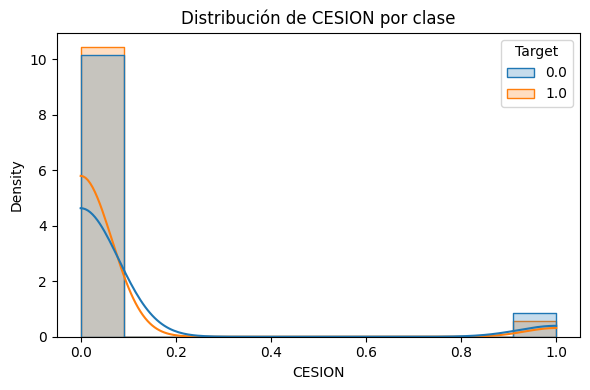

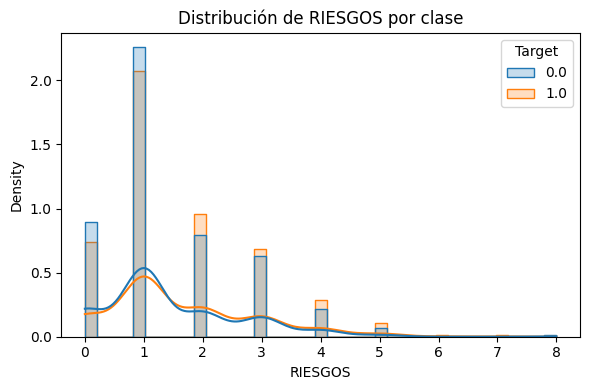

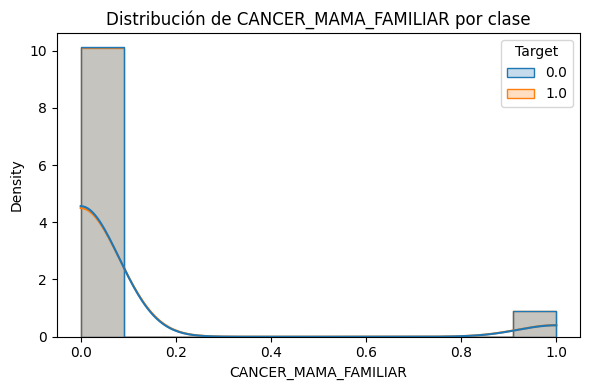

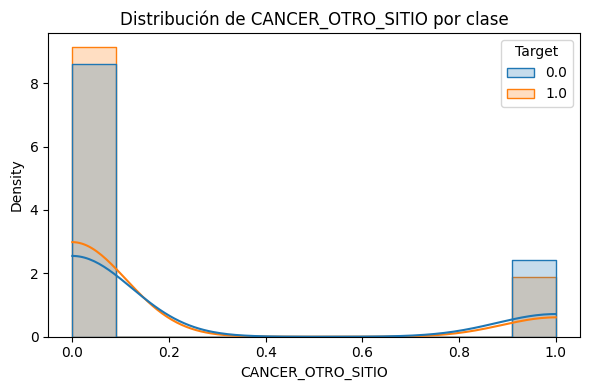

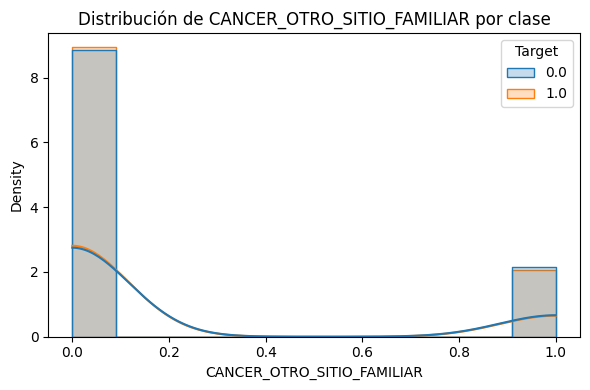

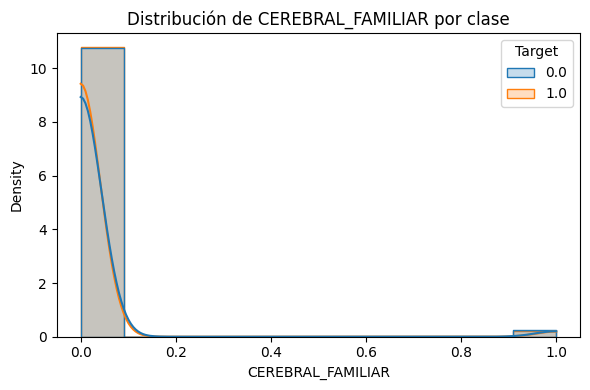

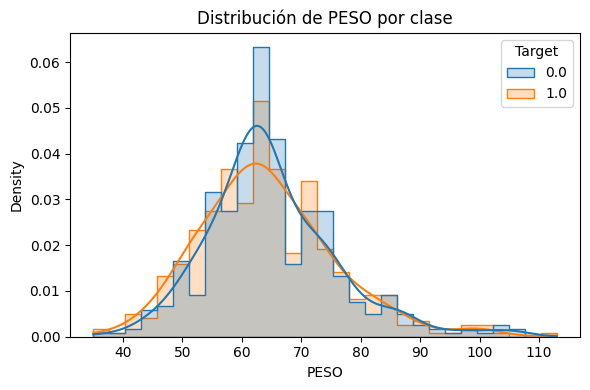

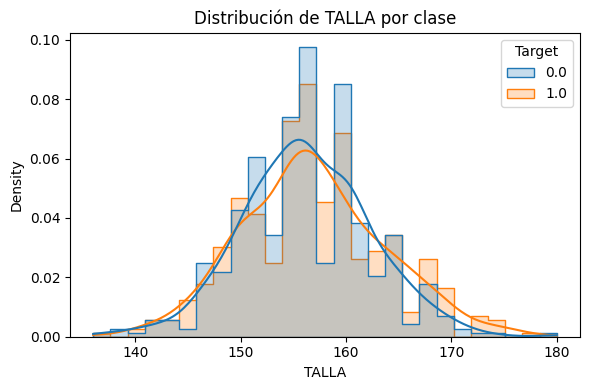

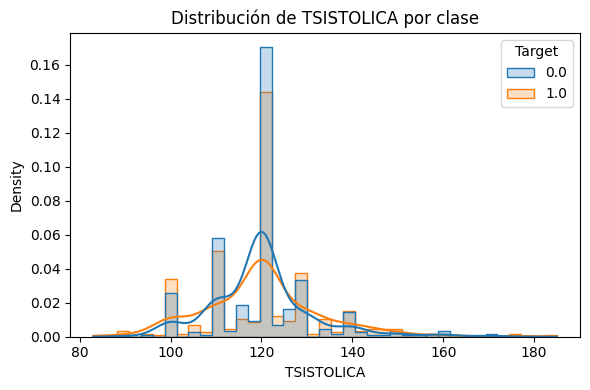

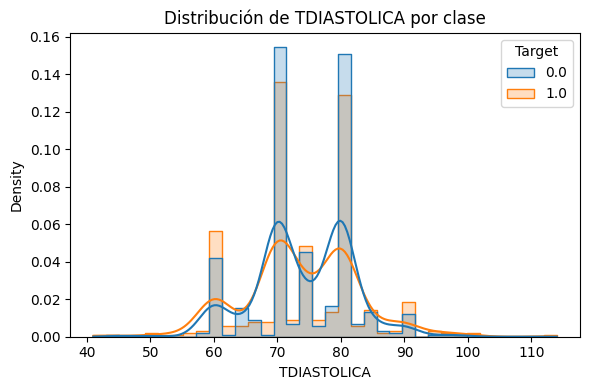

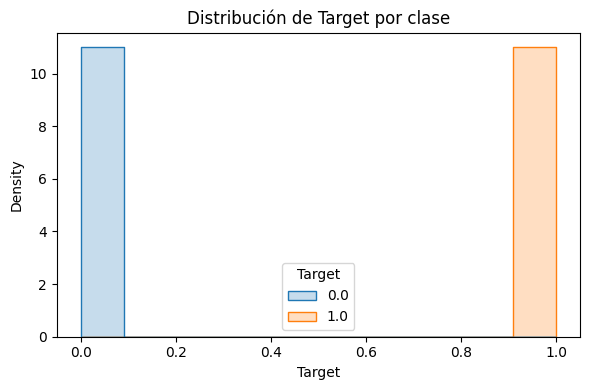

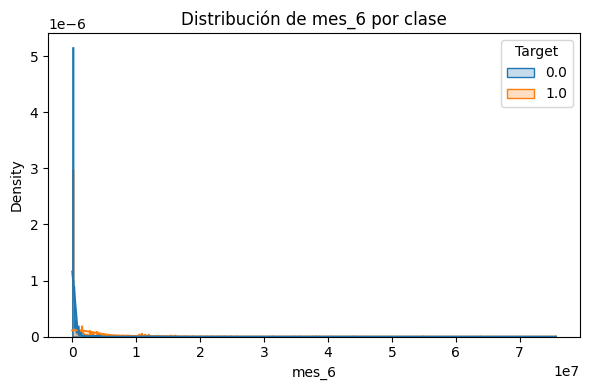

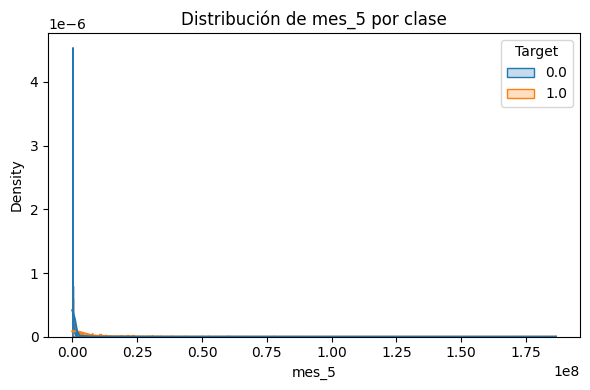

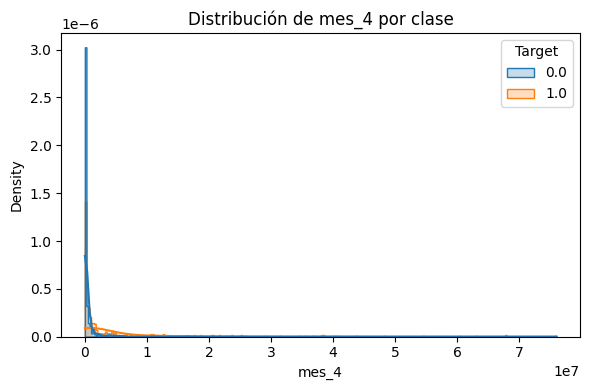

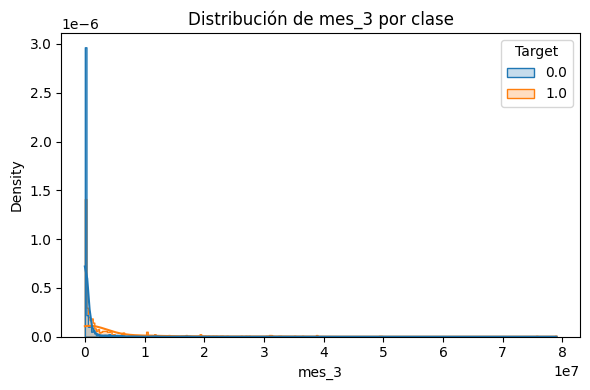

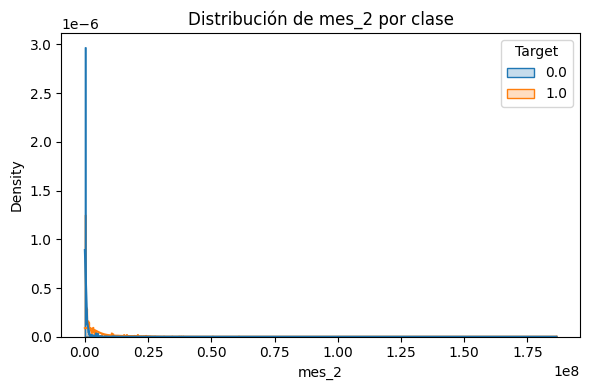

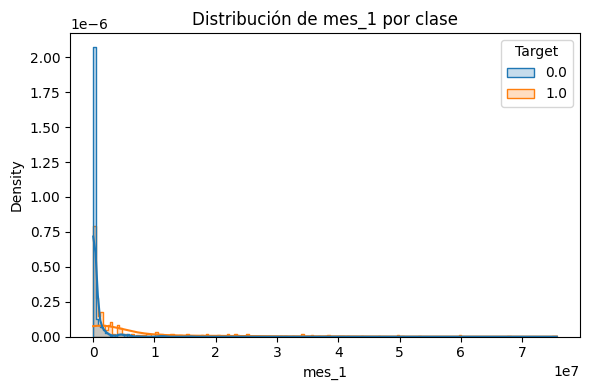

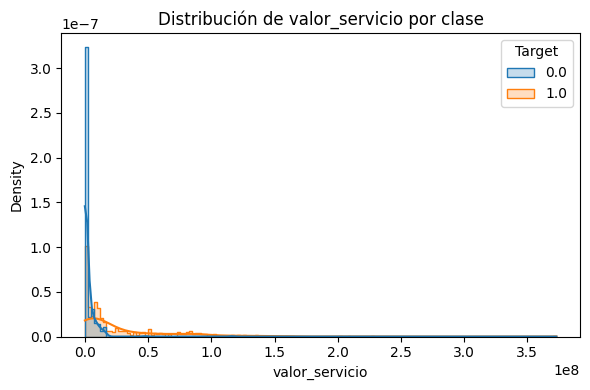

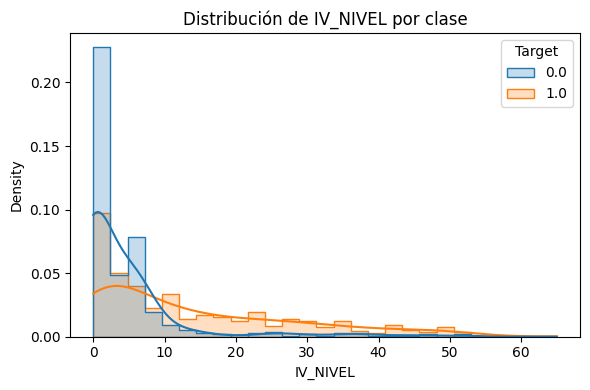

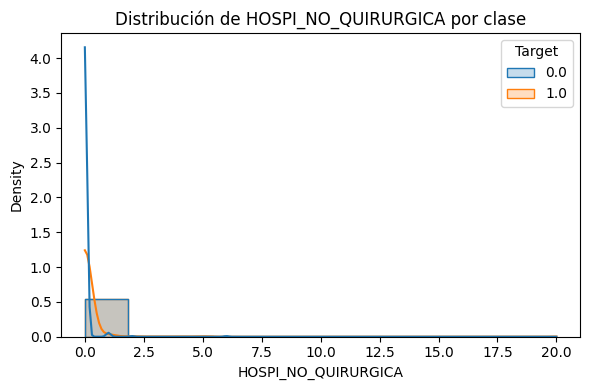

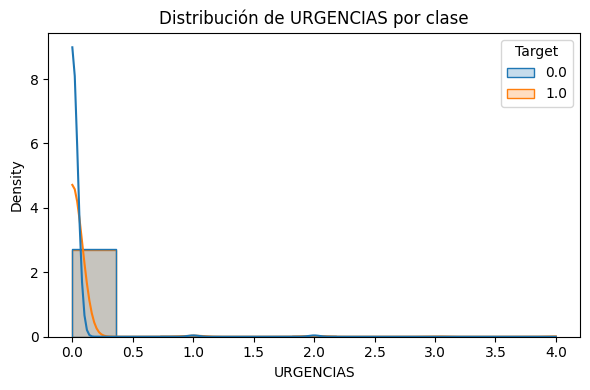

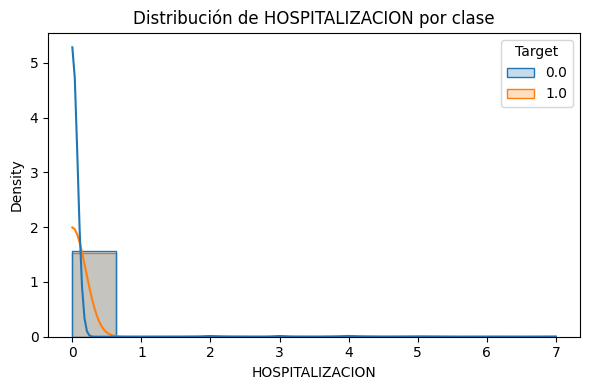

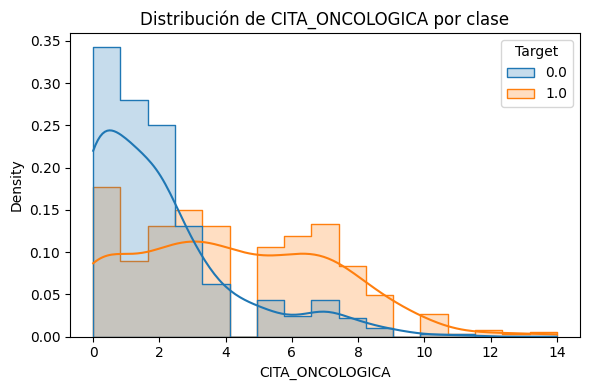

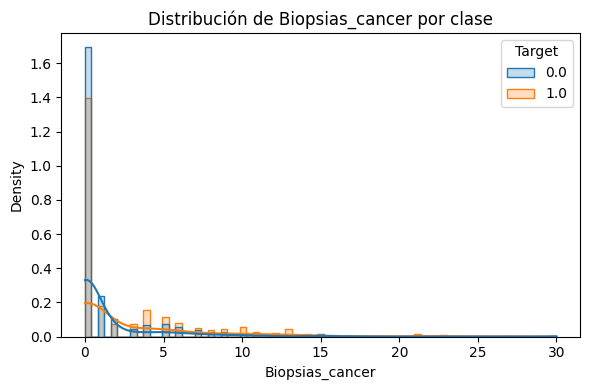

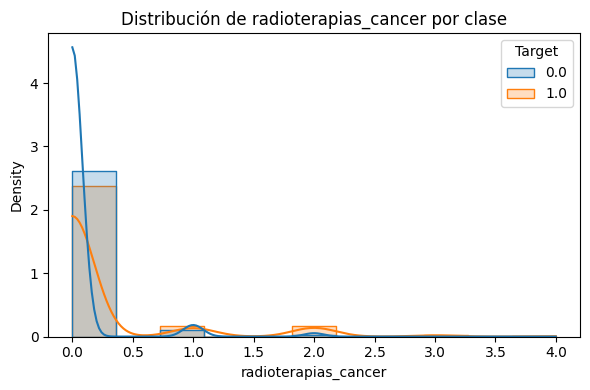

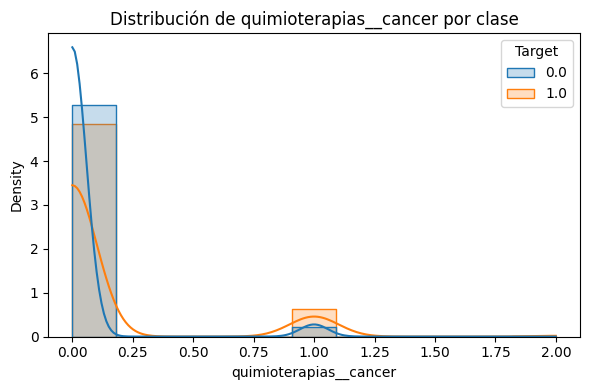

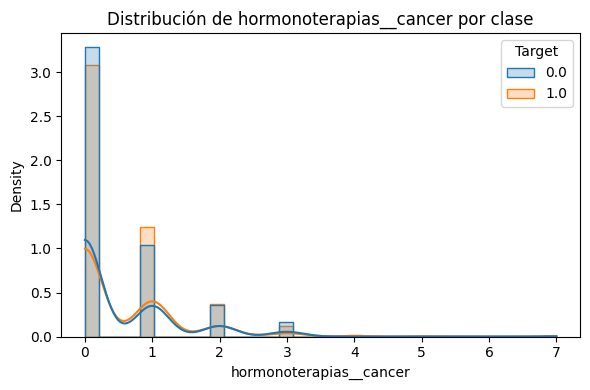

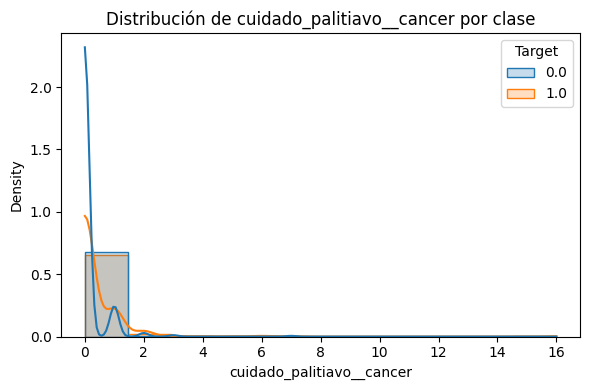

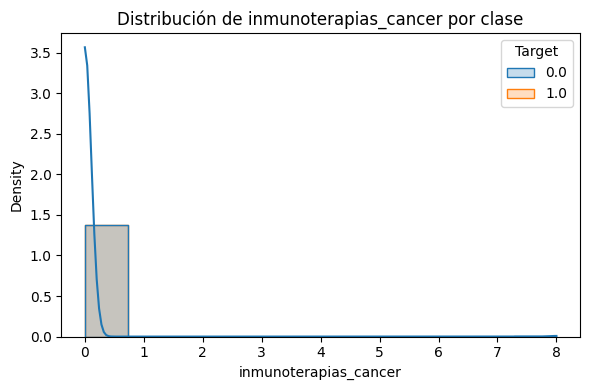

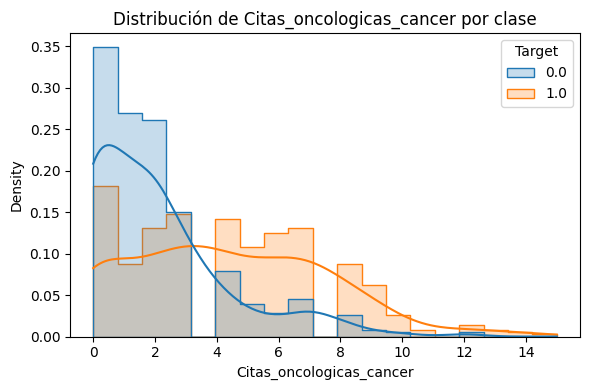

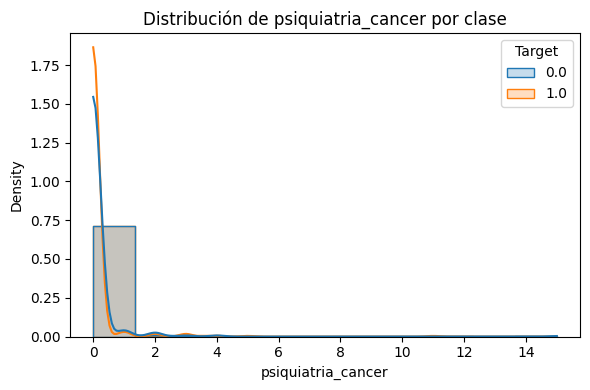

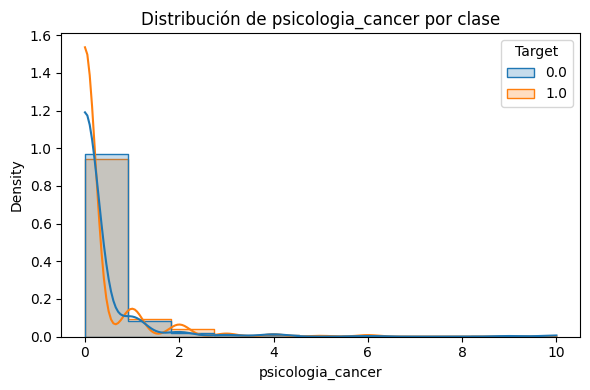

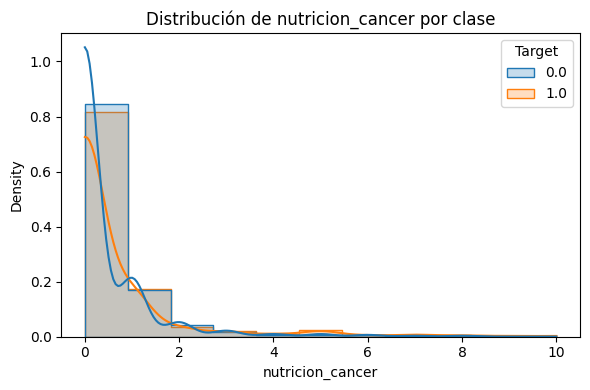

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(data=df_bal_1, x=col, hue='Target', kde=True, element="step", stat="density", common_norm=False)
    plt.title(f'Distribución de {col} por clase')
    plt.tight_layout()
    plt.show()


In [ ]:
print(df_bal_1["GENERO_M"].unique())

[False  True]


In [ ]:
# Tabla de contingencia entre GENERO_M y Target
conteo_genero_target = df_bal_1.groupby(["GENERO_M", "Target"]).size().unstack()

# Renombrar filas y columnas para mejor interpretación
conteo_genero_target.index = ["Femenino (GENERO_M=0)", "Masculino (GENERO_M=1)"]
conteo_genero_target.columns = ["Clase 0 (Target=0)", "Clase 1 (Target=1)"]

print(conteo_genero_target)


                        Clase 0 (Target=0)  Clase 1 (Target=1)
Femenino (GENERO_M=0)                  440                 426
Masculino (GENERO_M=1)                   7                  21


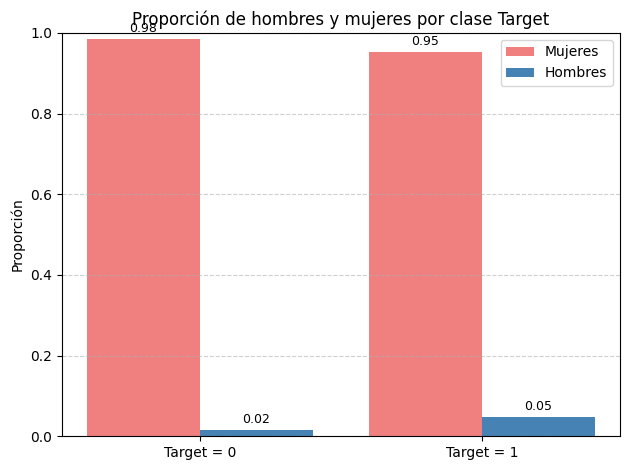

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Proporciones de hombres
prop_gen_m_target1 = df_bal_1[df_bal_1["Target"] == 1]["GENERO_M"].mean()
prop_gen_m_target0 = df_bal_1[df_bal_1["Target"] == 0]["GENERO_M"].mean()

# Proporciones de mujeres
prop_gen_f_target1 = 1 - prop_gen_m_target1
prop_gen_f_target0 = 1 - prop_gen_m_target0

# Datos para graficar
labels = ["Target = 0", "Target = 1"]
hombres = [prop_gen_m_target0, prop_gen_m_target1]
mujeres = [prop_gen_f_target0, prop_gen_f_target1]

x = np.arange(len(labels))  # posiciones X
width = 0.4

# Gráfico de barras
fig, ax = plt.subplots()
bars1 = ax.bar(x - width/2, mujeres, width, label="Mujeres", color="lightcoral")
bars2 = ax.bar(x + width/2, hombres, width, label="Hombres", color="steelblue")

# Etiquetas
for bar in bars1 + bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.2f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),  # separación vertical
                textcoords="offset points",
                ha='center', va='bottom', fontsize=9, color='black')

# Estética
ax.set_ylabel("Proporción")
ax.set_title("Proporción de hombres y mujeres por clase Target")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()
